# LIF Threshold, Reset, and Refractory Dynamics

This notebook extends the passive membrane model by adding threshold
detection, reset, an absolute refractory period, rheobase analysis,
and an analytical firing-rate prediction.

Spike Times: [27.726 55.452 83.178] ms


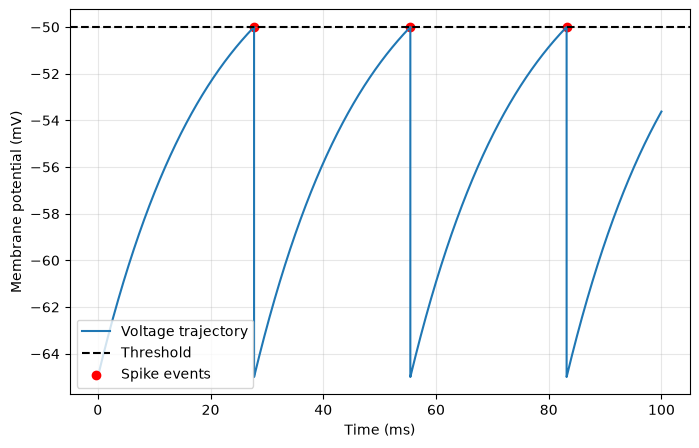

In [2]:
import numpy as np
import matplotlib.pyplot as plt 

i0 = 200e-12          # Ampere
v_threshold = -50e-3  # V
v_reset = -65e-3      # V
e_l = -65e-3          # V
v0 = -65e-3           # V
r_m = 100e6           # ohm
c_m = 200e-12         # F


tau = r_m * c_m
v_inf = i0 * r_m + e_l

def dv(v, v_inf, tau):
    return -(v - v_inf)/tau
    

dt = 1e-6            #s
t_end = 0.1          #s
time = np.arange(0, t_end, dt)

v = np.empty_like(time)
v[0] = v0


spike_times = []
for i in range(time.shape[0] - 1):
    dvdt = dv(v[i], v_inf, tau)
    v[i+1] = v[i] + dt * dvdt

    if v[i+1] >= v_threshold:
        v[i+1] = v_reset
        spike_times.append(time[i+1])

spike_times = np.array(spike_times)
print(f'Spike Times: {spike_times * 1e3} ms')

plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, v * 1e3, label = 'Voltage trajectory')
plt.axhline(v_threshold * 1e3, color = 'black', linestyle = '--', label = 'Threshold')
plt.scatter(
    spike_times * 1e3,
    np.ones_like(spike_times) * v_threshold * 1e3,
      color = 'red',
      label = 'Spike events')
plt.legend()
plt.grid(alpha = 0.3)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.show()


# Spike time 


Analytical solution is when $V(0) = V_{reset}$ :
$$
V(t) = V_\infty + (V_{reset} - V_\infty)\, e^{\frac{-t}{\tau_m}}
$$

Set $V(T) = V_{threshold}$ :
$$
V_{threshold} - V_\infty = (V_{reset} - V_\infty)\, e^{\frac{-T}{\tau_m}}\\[0.8cm]
$$

$$
e^{\frac{-T}{\tau_m}} = \frac{V_{threshold} - V_\infty}{(V_{reset} - V_\infty)}\\[0.6cm]
$$

$$
T = \tau_m \, ln(\frac{V_{reset} - V_\infty}{(V_{threshold} - V_\infty})\\[0.6cm]
$$


In [3]:
T = tau * np.log((v_reset - v_inf)/(v_threshold-v_inf))
print(f'Spike Time = {T * 1e3} ms')


Spike Time = 27.725887222397798 ms


Spike Times: [27.7 57.5 87.2] ms


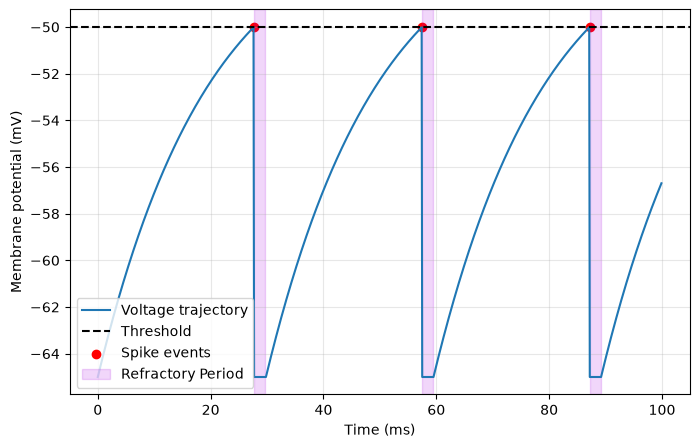

In [ ]:
t_refractory = 20 * 1e-3  #s
spike_times = []
refractory_cond = 0


dt = 1e-6                 #s
t_end = 0.1               #s
time = np.arange(0, t_end, dt)

v = np.empty_like(time)
v[0] = v0

for i in range(time.shape[0] - 1):

    if time[i] < refractory_cond:
        v[i+1] = v[i]
        continue

    dvdt = dv(v[i], v_inf, tau)
    v[i+1] = v[i] + dt * dvdt

    if v[i+1] >= v_threshold:
        v[i+1] = v_reset
        spike_times.append(time[i + 1])
        refractory_cond = time[i+1] + t_refractory

spike_times = np.array(spike_times)
print(f'Spike Times: {spike_times * 1e3} ms')

plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, v * 1e3, label = 'Voltage trajectory')
plt.axhline(v_threshold * 1e3, color = 'black', linestyle = '--', label = 'Threshold')

plt.scatter(
    spike_times * 1e3,
    np.ones_like(spike_times) * v_threshold * 1e3,
      color = 'red',
      label = 'Spike events')

plt.grid(alpha = 0.3)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')

for j in range(spike_times.shape[0]):
    label = 'Refractory Period' if j == 0 else None 

    plt.axvspan(
        spike_times[j] * 1e3,
        (spike_times[j] + t_refractory) * 1e3, 
        color = "#a903e1",
        label = label,
        alpha = 0.16
        )


    
plt.legend()
plt.show()



# Rheobase Current
- It is the amount of constant current needed to generate a spike. 

$$
\\[0.5cm]
V_\infty = E_L+ R_m I_0
\\[0.5cm]
$$

- The rheobase is the boundary current for which $V_\infty=V_{\mathrm{threshold}}$. At exact equality, the voltage approaches threshold asymptotically and does not spike in finite time. Therefore, the ideal LIF neuron fires only when $I_0>I_{\mathrm{rh}}$.

$$
\\[0.6cm] V_{threshold} = E_L+ R_m I_0 \\[0.8cm]
$$

$$
I_0 = \frac{V_{threshold} - E_L}{R_m} \\[0.3cm]
$$
- $I_0$ here is called Rheobase current $I_{rh}$ :

$$
I_{rh} = \frac{V_{threshold} - E_L}{R_m}
$$

$$\\[0.9cm]$$
- So spikes happen when:


$$
\\[0.4cm]
I_0 > I_{rh}
$$

$$
\\[0.4cm]
I_0 > \frac{V_{threshold} - E_L}{R_m}
$$





In [5]:
I_rh = (v_threshold - e_l) / r_m
print(f'Rheobase Current = {I_rh} A  or {I_rh * 1e12} pA')
print(f'i0               = {i0}   A  or {i0 * 1e12} pA')
print(f'i0 > I_rh: {i0 > I_rh}')

Rheobase Current = 1.5e-10 A  or 150.0 pA
i0               = 2e-10   A  or 200.0 pA
i0 > I_rh: True


# Spike Frequency

$$\large
T_{total} = T_{ref} + \tau_m \, ln(\frac{V_{reset} - V_\infty}{(V_{threshold} - V_\infty})\\[0.6cm]
$$

$$\large
f = \frac{1}{T_{total}}\\[0.8cm]
$$

$$\large
f = \frac{1}{T_{ref} + \tau_m \, ln(\frac{V_{reset} - V_\infty}{(V_{threshold} - V_\infty})}\\[0.8cm]
$$

$$\large
f(I_0) = \frac{1}{T_{ref} + \tau_m \, ln(\frac{V_{reset} - E_L - R_mI_0}{(V_{threshold} - E_L-R_mI_0})}\\[0.8cm]
$$


$$ \large
f(I_0) = \begin{cases}

        0 & \text {if} & I_0 \le I_{rh} \\[0.5cm]

        \frac{1}{T_{ref} + \tau_m \, ln(\frac{V_{reset} - E_L-R_mI_0}{(V_{threshold} - E_L-R_mI_0})} & \text {if} & I_0 > I_{rh}

        \end{cases}
$$

In [6]:
# For i0 = 200 pA:

T_total = T + t_refractory
f = 1/(T_total)
print(f'Frequency = {f} Hz')


Frequency = 33.640711630182125 Hz
